# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [10]:
corpus = '''
Artificial intelligence is one of the most transformative technologies of the modern era. It enables machines to perform tasks that traditionally required human intelligence, such as recognizing speech, understanding language, solving problems, and making decisions. Over the past decade, advances in computing power, data availability, and machine learning algorithms have accelerated the development of intelligent systems across various industries.
Machine learning is a subset of artificial intelligence that focuses on enabling computers to learn from data without being explicitly programmed. Instead of following fixed rules, machine learning models identify patterns within data and use those patterns to make predictions or decisions. These models improve their performance over time as they are exposed to more data and experiences.
Deep learning is a specialized branch of machine learning that utilizes artificial neural networks with multiple hidden layers. Inspired by the structure of the human brain, neural networks process information through interconnected nodes called neurons. Deep learning models have achieved remarkable success in tasks such as image recognition, natural language processing, speech synthesis, and autonomous driving.
Natural language processing is a field of artificial intelligence that focuses on the interaction between computers and human language. It enables machines to understand, interpret, and generate text in a meaningful way. Applications of natural language processing include machine translation, sentiment analysis, text summarization, question answering systems, and conversational chatbots.
Text generation is one of the most fascinating applications of natural language processing. In text generation, a model learns the structure, grammar, and contextual relationships within a collection of text. After training, the model can generate new sentences that resemble the patterns observed in the training data. Text generation systems are widely used in virtual assistants, content creation, automated storytelling, and educational tools.
Recurrent neural networks are specifically designed for sequential data. Unlike traditional neural networks, recurrent neural networks maintain information about previous inputs through internal memory states. This characteristic makes them suitable for tasks involving text, speech, and time series data. However, traditional recurrent neural networks often struggle with learning long-term dependencies due to the vanishing gradient problem.
Long Short-Term Memory networks were developed to address the limitations of traditional recurrent neural networks. LSTM networks contain memory cells and gating mechanisms that regulate the flow of information through the network. These gates allow the model to retain important information for extended periods and discard irrelevant details. As a result, LSTM networks are highly effective at capturing long-term dependencies in sequential data.
Gated Recurrent Units are another type of recurrent neural network architecture designed to improve memory handling and training efficiency. GRU networks simplify the gating mechanism used in LSTM models while maintaining strong performance. They typically require fewer parameters and less computational power, making them a popular choice for many sequence modeling tasks.
The ability to learn contextual relationships is essential for generating coherent and meaningful text. Context helps determine the meaning of words based on surrounding information. For example, the same word may have different meanings depending on the sentence in which it appears. Deep learning models use context to predict the most appropriate next word in a sequence, resulting in more natural and fluent text generation.
As artificial intelligence continues to evolve, text generation systems are becoming increasingly sophisticated. Modern language models can generate detailed explanations, answer questions, summarize documents, and assist users with a wide range of tasks. These advancements demonstrate the potential of deep learning techniques to revolutionize human computer interaction and transform the way information is created and shared.
'''
print(corpus)


Artificial intelligence is one of the most transformative technologies of the modern era. It enables machines to perform tasks that traditionally required human intelligence, such as recognizing speech, understanding language, solving problems, and making decisions. Over the past decade, advances in computing power, data availability, and machine learning algorithms have accelerated the development of intelligent systems across various industries.
Machine learning is a subset of artificial intelligence that focuses on enabling computers to learn from data without being explicitly programmed. Instead of following fixed rules, machine learning models identify patterns within data and use those patterns to make predictions or decisions. These models improve their performance over time as they are exposed to more data and experiences.
Deep learning is a specialized branch of machine learning that utilizes artificial neural networks with multiple hidden layers. Inspired by the structure of

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


 Model 1: Vanilla RNN


In [14]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),  # Increased embedding dimension from 32 to 64
    SimpleRNN(128),   # Increased hidden units from 64 to 128
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)   #Increased epochs
print("Vanilla RNN training completed")

Vanilla RNN training completed


Model 2: LSTM


In [15]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),   # Increased LSTM units from 64 → 128
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)   #Increased epochs
print("LSTM training completed")

LSTM training completed


 Model 3: GRU


In [16]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),    # Increased GRU units from 64 → 128
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


Comparing Training Loss

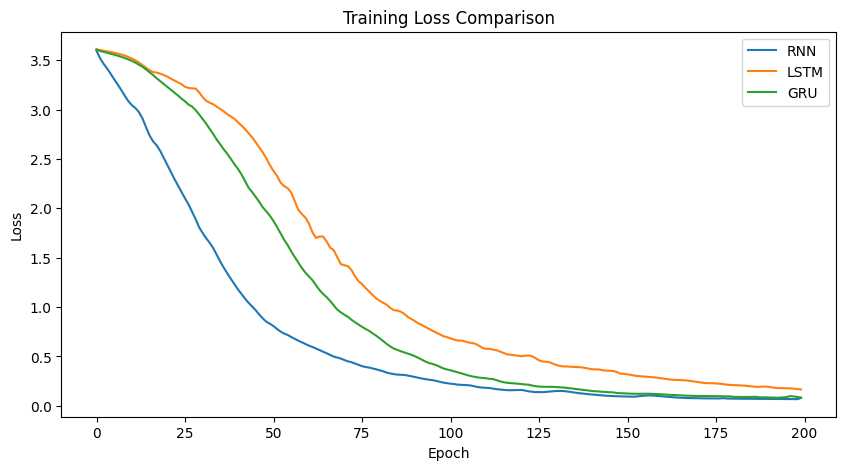

In [18]:
plt.figure(figsize=(10,5))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

Comparing Accuracy

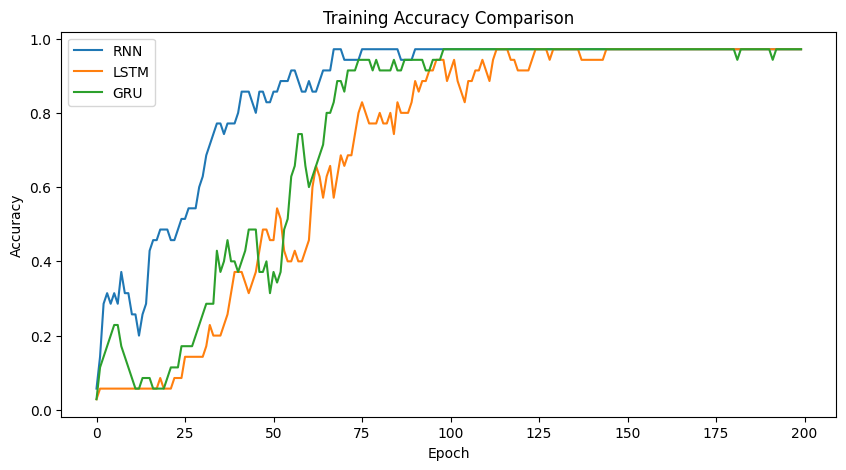

In [25]:
plt.figure(figsize=(10,5))

plt.plot(rnn_history.history['accuracy'], label='RNN')
plt.plot(lstm_history.history['accuracy'], label='LSTM')
plt.plot(gru_history.history['accuracy'], label='GRU')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Comparison')
plt.legend()
plt.show()

In [23]:
#Final loss and accuracy
print("RNN Final Loss:", round(rnn_history.history['loss'][-1],4))
print("RNN Final Accuracy:", round(rnn_history.history['accuracy'][-1],4))

print("\nLSTM Final Loss:", round(lstm_history.history['loss'][-1],4))
print("LSTM Final Accuracy:", round(lstm_history.history['accuracy'][-1],4))

print("\nGRU Final Loss:", round(gru_history.history['loss'][-1],4))
print("GRU Final Accuracy:", round(gru_history.history['accuracy'][-1],4))

RNN Final Loss: 0.0798
RNN Final Accuracy: 0.9714

LSTM Final Loss: 0.1658
LSTM Final Accuracy: 0.9714

GRU Final Loss: 0.0837
GRU Final Accuracy: 0.9714


In [24]:
#Model summary
print("RNN Summary")
rnn_model.summary()

print("LSTM Summary")
lstm_model.summary()

print("GRU Summary")
gru_model.summary()

RNN Summary


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 7, 64)          │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,537 (373.20 KB)

 Trainable params: 31,845 (124.39 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 7, 64)          │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,913 (956.70 KB)

 Trainable params: 81,637 (318.89 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 163,276 (637.80 KB)

Text Generation Function


In [19]:
def generate_text(model, seed_text, next_words=10):   #Generate 10 words instead of 5
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

 Generate Text Samples

 >> My corpus is still very small for text generation so when I am asking for a text of 10 words, it has very limited patterns to continue from.

In [22]:
print("RNN :", generate_text(rnn_model, "artificial intelligence", 10))
print("LSTM:", generate_text(lstm_model, "artificial intelligence", 10))
print("GRU :", generate_text(gru_model, "artificial intelligence", 10))

RNN : artificial intelligence neural is faster and simpler than lstm helps remember long
LSTM: artificial intelligence generation models the next word word word word word word
GRU : artificial intelligence models can generate meaningful sentences sentences sentences sentences data data


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**